# 01 Exploratory Data Analysis (EDA)

Objective: Understand the BTC-USD price dataset, visualize distributions, and identify outliers or seasonal trends.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
file_path = r"C:\Users\David\BTC-trend-prediction\data\raw\coin_Bitcoin.csv"

df = pd.read_csv(data_path, parse_dates=['Date'])

df.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


In [51]:
df = df.sort_values('Date').reset_index(drop=True)
#sorting dates from oldest to newest, but in this case it already did

In [52]:
df.info

<bound method DataFrame.info of        SNo     Name Symbol                Date          High           Low  \
0        1  Bitcoin    BTC 2013-04-29 23:59:59    147.488007    134.000000   
1        2  Bitcoin    BTC 2013-04-30 23:59:59    146.929993    134.050003   
2        3  Bitcoin    BTC 2013-05-01 23:59:59    139.889999    107.720001   
3        4  Bitcoin    BTC 2013-05-02 23:59:59    125.599998     92.281898   
4        5  Bitcoin    BTC 2013-05-03 23:59:59    108.127998     79.099998   
...    ...      ...    ...                 ...           ...           ...   
2986  2987  Bitcoin    BTC 2021-07-02 23:59:59  33939.588699  32770.680780   
2987  2988  Bitcoin    BTC 2021-07-03 23:59:59  34909.259899  33402.696536   
2988  2989  Bitcoin    BTC 2021-07-04 23:59:59  35937.567147  34396.477458   
2989  2990  Bitcoin    BTC 2021-07-05 23:59:59  35284.344430  33213.661034   
2990  2991  Bitcoin    BTC 2021-07-06 23:59:59  35038.536363  33599.916169   

              Open         Clos

In [53]:
df.isnull().sum()
#checking for missing data
#no missing values in this dataset

SNo          0
Name         0
Symbol       0
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Marketcap    0
dtype: int64

In [68]:

df.drop(columns=['SNo','Name','Symbol'], inplace=True)

In [69]:
df['Daily_Returns'] = df['Close'].pct_change()
df = df.dropna()

<function matplotlib.pyplot.show(close=None, block=None)>

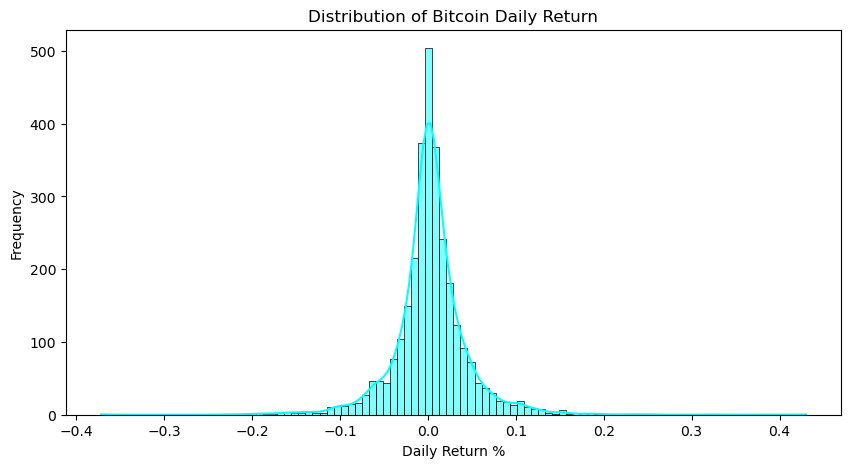

In [70]:
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Returns'], bins=100, kde=True, color='cyan')
plt.title('Distribution of Bitcoin Daily Return')
plt.xlabel('Daily Return %')
plt.ylabel('Frequency')
plt.show

In [71]:
#calculates how oftern bitcoin goes up
win_rate = (df['Daily_Returns'] > 0).mean() * 100
print(f"Bitcoin closes green {win_rate:.2f}% of the time")

Bitcoin closes green 54.07% of the time


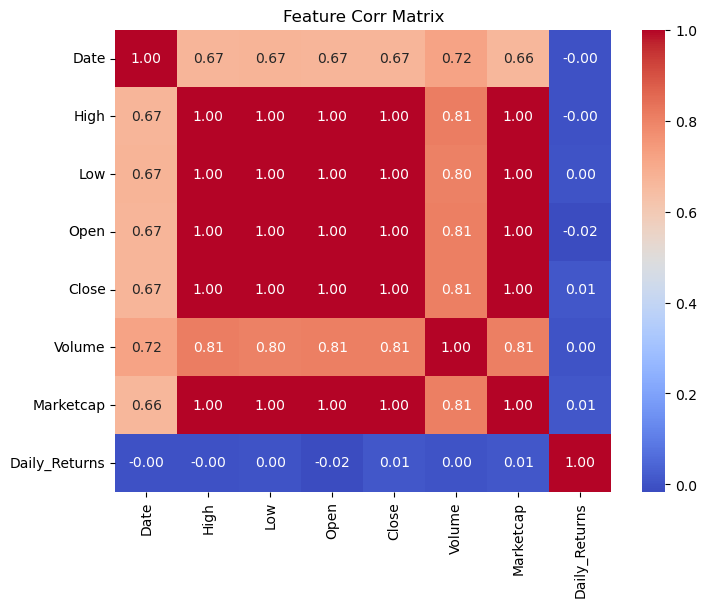

In [72]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Corr Matrix')
plt.show()
